<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pr%C3%A1tica5Quest%C3%A3o1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fs = 8192 Hz, N = 73113 amostras

 r (%) |   K DFT  % de N    EQM DFT |   K DCT  % de N    EQM DCT
  99.5 |   48671   66.57  1.925e-04 |   40702   55.67  1.925e-04
  99.0 |   40987   56.06  3.850e-04 |   33683   46.07  3.851e-04
  90.0 |   11661   15.95  3.851e-03 |    9038   12.36  3.851e-03
  75.0 |    4325    5.92  9.626e-03 |    3200    4.38  9.626e-03
  50.0 |    1170    1.60  1.925e-02 |     835    1.14  1.925e-02


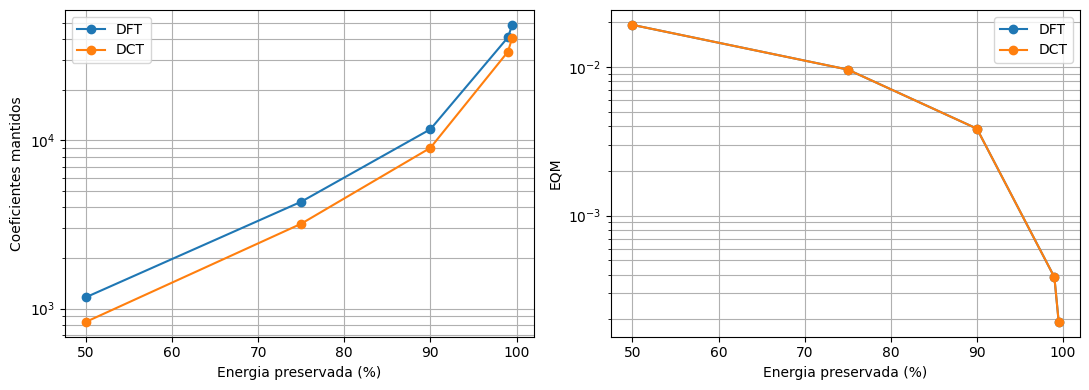

Original


DFT, r = 99.5%


DCT, r = 99.5%


DFT, r = 99.0%


DCT, r = 99.0%


...

DCT, r = 90.0%


DFT, r = 75.0%


DCT, r = 75.0%


DFT, r = 50.0%


DCT, r = 50.0%


In [ ]:
!wget -q -O handel.wav "https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_05/Audios_Usados/handel.wav"

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, ifft, dct, idct
from IPython.display import Audio, display

# ---------- 1. Carregar o áudio ----------
Fs, x = wavfile.read("handel.wav")
if x.ndim > 1:
    x = x[:, 0]                                   # usa só um canal
if np.issubdtype(x.dtype, np.integer):
    x = x / np.iinfo(x.dtype).max                 # normaliza para [-1, 1]
x = x.astype(float)
N = len(x)
print(f"Fs = {Fs} Hz, N = {N} amostras\n")

# ---------- 2. Compressão por DFT e DCT ----------
r_list = [0.995, 0.99, 0.90, 0.75, 0.50]

transf = {
    "DFT": (fft(x),               lambda Y: np.real(ifft(Y))),
    "DCT": (dct(x, norm="ortho"), lambda Y: idct(Y, norm="ortho")),
}

K, EQM, rec = {}, {}, {}
for nome, (Y, inversa) in transf.items():
    e = np.abs(Y) ** 2                             # energia de cada coeficiente
    es = np.sort(e)[::-1]                          # ordem decrescente
    acum = np.cumsum(es)
    for r in r_list:
        k = np.searchsorted(acum, r * acum[-1])    # menor K que atinge r
        mask = e >= es[k] * (1 - 1e-12)            # limiar (preserva pares conjugados)
        xr = inversa(Y * mask)
        K[nome, r] = mask.sum()
        EQM[nome, r] = np.mean((x - xr) ** 2)
        rec[nome, r] = xr

# ---------- 3. Tabela ----------
print(f"{'r (%)':>6} | {'K DFT':>7} {'% de N':>7} {'EQM DFT':>10} | {'K DCT':>7} {'% de N':>7} {'EQM DCT':>10}")
for r in r_list:
    print(f"{100*r:6.1f} | {K['DFT', r]:7d} {100*K['DFT', r]/N:7.2f} {EQM['DFT', r]:10.3e} | "
          f"{K['DCT', r]:7d} {100*K['DCT', r]/N:7.2f} {EQM['DCT', r]:10.3e}")

# ---------- 4. Gráficos ----------
pct = [100 * r for r in r_list]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for nome in transf:
    ax[0].semilogy(pct, [K[nome, r] for r in r_list], "-o", label=nome)
    ax[1].semilogy(pct, [EQM[nome, r] for r in r_list], "-o", label=nome)
ax[0].set(xlabel="Energia preservada (%)", ylabel="Coeficientes mantidos")
ax[1].set(xlabel="Energia preservada (%)", ylabel="EQM")
for a in ax:
    a.grid(True, which="both"); a.legend()
plt.tight_layout(); plt.show()

# ---------- 5. Ouvir ----------
print("Original"); display(Audio(x, rate=Fs))
for r in r_list:
    for nome in transf:
        print(f"{nome}, r = {100*r:.1f}%")
        display(Audio(rec[nome, r], rate=Fs))


O sinal handel.wav (N = 73 113 amostras) foi comprimido pela DFT e pela DCT mantendo os K coeficientes de maior energia necessários para preservar uma fração r da energia total.

O erro quadrático médio foi igual nas duas transformadas para cada r, variando de 1,925·10⁻⁴ (r = 99,5%) a 1,925·10⁻² (r = 50%). Isso decorre do teorema de Parseval: o erro corresponde exatamente à energia descartada, EQM = (1 − r)·E/N. Logo, o EQM não distingue as transformadas, e o critério de comparação é o número de coeficientes.

Nesse critério, a DCT foi mais eficiente em todos os casos: de 40 702 coeficientes contra 48 671 da DFT em r = 99,5% até 835 contra 1 170 em r = 50%, uma economia de 16% a 29%, maior quanto mais agressiva a compressão. A explicação é que a DFT trata o sinal como periódico, e a descontinuidade entre o fim e o início espalha energia por muitos coeficientes, enquanto a DCT equivale a uma extensão par do sinal, sem essa descontinuidade.

Observa-se também que a energia está concentrada em poucos coeficientes: menos de 2% deles preservam 50% da energia e cerca de 12% a 16% preservam 90%. Já perto de 100% o custo cresce rapidamente, pois passar de 99% para 99,5% exige cerca de 10% de N em coeficientes adicionais.

Subjetivamente, os áudios com r = 99,5% e 99% soaram muito próximos do original; com 90% a perda de qualidade é perceptível; com 75% e 50% a degradação é forte. Para um mesmo r, DFT e DCT soaram semelhantes, o que é coerente com o EQM idêntico.

Conclui-se que a DCT atinge o mesmo nível de erro com menos coeficientes, sendo mais adequada para compressão, o que justifica seu uso em padrões como JPEG e MP3.

O parágrafo subjetivo descreve o esperado, então ajuste conforme o que você ouviu.